# Caretta Lab IV Sweep Testing Notebook

This python notebook provides an interactive interface with the IV sweep measurement functionality available in the open source Python Integrated Experiment Control (piec) package. The IV sweep uses a sourcemeter to step voltage from a start to stop value, measuring current at each step to characterize the current-voltage relationship of a device. Code documentation and setup details can be found at https://piec.readthedocs.io.

*COPY THIS NOTEBOOK AND RUN IN A LOCAL DIRECTORY TO PREVENT IT FROM BEING OVERWRITTEN BY GITHUB*

### Imports

In [1]:
from piec.drivers.sourcemeter.virtual_keithley2400 import VirtualKeithley2400
from piec.measurement.iv_sweep import IVSweep
from piec.analysis.utilities import standard_csv_to_metadata_and_data
from piec.drivers.utilities import PiecManager

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [2]:
pm = PiecManager()
pm.list_resources()

c:\Users\Jesalina Phan\AppData\Local\Programs\Python\Python312\Lib\site-packages\pyvisa_py\tcpip.py:122: UserWarning: TCPIP::hislip resource discovery requires the zeroconf package to be installed... try 'pip install zeroconf'
  warnings.warn(


()

### Instrument Setup

The IV sweep requires one instrument:
- **Sourcemeter** (sourcemeter): Sources voltage and measures current simultaneously. Typically a Keithley 2400.

In piec, each instrument is represented by a class object. Initialize it with the appropriate VISA address. Use `'VIRTUAL'` to run in simulation mode without real hardware.

In [3]:
sourcemeter = VirtualKeithley2400()  # Sourcemeter: 'GPIB0::24::INSTR' for real, VirtualKeithley2400() for simulation

print('Sourcemeter: ', sourcemeter.idn())

Sourcemeter:  Virtual Keithley 2400


### IV Sweep Measurement

The IV sweep steps voltage linearly from `v_start` to `v_stop` in `num_steps` steps. At each step, the sourcemeter waits `dwell_time` seconds then records the measured voltage and current. The result is an I-V curve characterizing the device under test.

Key parameters:
- **v_start**: Starting voltage in Volts.
- **v_stop**: Ending voltage in Volts.
- **num_steps**: Number of voltage steps in the sweep.
- **current_compliance**: Maximum allowed current in Amps — protects the device from overcurrent.
- **dwell_time**: Time to wait at each voltage step before measuring (seconds).
- **sense_mode**: `'2W'` for 2-wire (remote sense off) or `'4W'` for 4-wire (Kelvin) sensing.

In [4]:
### VARIABLE DEFINITIONS ###

path = r"scratch"   # path to save data, make sure directory exists and you have permissions

v_start = 0.0       # starting voltage (V)
v_stop = 1.0        # ending voltage (V)
num_steps = 50      # number of voltage steps
current_compliance = 0.1  # current compliance limit (A)
dwell_time = 0.1    # wait time at each step before measuring (s)
sense_mode = '2W'   # sensing mode: '2W' or '4W'

In [5]:
### RUN ###

experiment = IVSweep(
    sourcemeter=sourcemeter,
    v_start=v_start,
    v_stop=v_stop,
    num_steps=num_steps,
    current_compliance=current_compliance,
    dwell_time=dwell_time,
    sense_mode=sense_mode,
    save_dir=path,
)

# Run the experiment — this will configure the sourcemeter,
# step through voltages capturing data, save results, and return.
experiment.run_experiment()

Running IV sweep experiment...
Sourcemeter configured.
Starting IV sweep: 0.0V to 1.0V in 50 steps...
  Step 5/50: V=0.0816 V, I=0.000000e+00 A
  Step 10/50: V=0.1837 V, I=0.000000e+00 A
  Step 15/50: V=0.2857 V, I=0.000000e+00 A
  Step 20/50: V=0.3878 V, I=0.000000e+00 A
  Step 25/50: V=0.4898 V, I=0.000000e+00 A
  Step 30/50: V=0.5918 V, I=0.000000e+00 A
  Step 35/50: V=0.6939 V, I=0.000000e+00 A
  Step 40/50: V=0.7959 V, I=0.000000e+00 A
  Step 45/50: V=0.8980 V, I=0.000000e+00 A
  Step 50/50: V=1.0000 V, I=0.000000e+00 A
Sweep complete.
Output off.
IV sweep data saved to scratch\0_iv_sweep_0p0V_to_1p0V.csv
Experiment complete.


In [6]:
# Retrieve the captured data for further analysis
iv_metadata, iv_df = standard_csv_to_metadata_and_data(experiment.filename)
iv_df.head()

,voltage (V),current (A)
0,0.000000,0.0
1,0.020408,0.0
2,0.040816,0.0
3,0.061224,0.0
4,0.081633,0.0


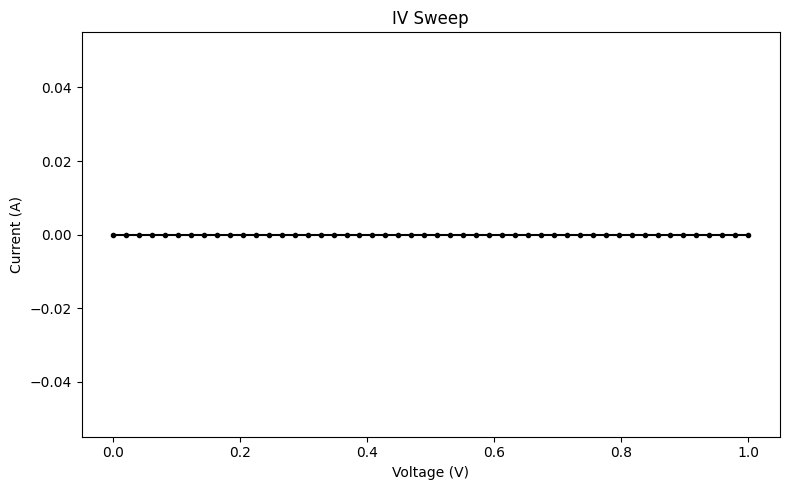

In [7]:
# Plot the IV curve: current vs voltage
iv_df.plot(x="voltage (V)", y="current (A)", figsize=(8, 5), marker=".", color="k", legend=False)
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.title("IV Sweep")
plt.tight_layout()
plt.show()